# F78DS Coursework 2
- Student Details
  - Student Name: Qing Hao, Too
  - Student ID: H00467830
  - Course: F78DS - Data Science Life Cycle
  - Assignment: Coursework 1
  - Due Date: 7th April 2026, 5:00PM (M'sia)

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score

In [56]:
init = pd.read_csv('data/F78DS-Essay-Features.csv')

In [57]:
init.columns

Index(['essayid', 'chars', 'words', 'commas', 'apostrophes', 'punctuations',
       'avg_word_length', 'sentences', 'questions', 'avg_word_sentence', 'POS',
       'POS/total_words', 'prompt_words', 'prompt_words/total_words',
       'synonym_words', 'synonym_words/total_words', 'unstemmed', 'stemmed',
       'score'],
      dtype='str')

Via the cell below, we can _see_ there exists outliers everywhere. It could become dangerous, as it begs the question, "To remove or not to remove the outliers".

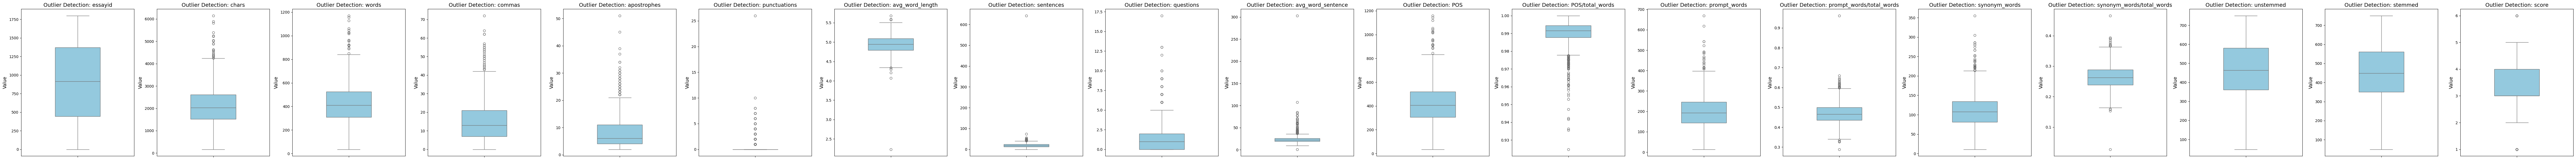

In [58]:
# Visualise outliers using boxplot
def plot_individual_boxplots(df):
    num_cols = len(df.select_dtypes(include=['number']).columns)
    
    # Create subplots side-by-side
    fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 6))
    
    # Handle single column case
    if num_cols == 1:
        axes = [axes]
    
    # Loop through columns and create a boxplot for each
    for i, col in enumerate(df.select_dtypes(include=['number']).columns):
        sns.boxplot(y=df[col], ax=axes[i], color="skyblue", width=0.4)
        axes[i].set_title(f'Outlier Detection: {col}', fontsize=14)
        axes[i].set_ylabel('Value', fontsize=12)
        
    plt.tight_layout()
    plt.savefig('standard_outlier_boxplots.png')

plot_individual_boxplots(init)

To handle the outliers, we use the function `pluck()`, which enables us to cherry pick the tails of the data we want to remove. While may, or may not improve accuracy, it also introduces biasness.

In [59]:
def pluck(df, rules):
    """
    Non-cumulative version - an essay is only removed if it violates ANY rule
    """
    keep_mask = pd.Series(True, index=df.index)
    
    for col, (side, p) in rules.items():
        if col not in df.columns:
            continue
            
        if side in ['top', 'both']:
            upper_limit = df[col].quantile(1 - p)
            keep_mask &= (df[col] <= upper_limit)
            
        if side in ['bottom', 'both']:
            lower_limit = df[col].quantile(p)
            keep_mask &= (df[col] >= lower_limit)
    
    return df[keep_mask]

In [60]:
# Define your custom "Cherry Plucking" rules
cleaning_rules = {
    # Physical limits (impossible values)
    'chars': ('both', 0.001),        # Only remove true outliers (0.1%)
    'words': ('both', 0.001),         # Same
    
    # Grammar features - very conservative
    'commas': ('top', 0.01),           # 1% - keep most
    'apostrophes': ('top', 0.01),       # 1%
    'punctuations': ('top', 0.01),      # 1%
    
    # Structure features
    'sentences': ('top', 0.01),         # 1%
    'questions': ('top', 0.01),          # 1%
    'avg_word_sentence': ('top', 0.01),  # 1%
    
    # Vocabulary features - be gentler
    'POS': ('top', 0.02),                # 2% - vocabulary richness is good
    'POS/total_words': ('both', 0.02),   # 2% both sides
    
    # Content relevance - keep most
    'prompt_words': ('top', 0.02),        # 2%
    'prompt_words/total_words': ('top', 0.02),  # 2%
    
    # Synonyms - keep most
    'synonym_words': ('top', 0.02),       # 2%
    'synonym_words/total_words': ('both', 0.02),  # 2%
    
    # Word processing
    'avg_word_length': ('bottom', 0.005), # 0.5% - only remove truly short words
}

# Before cleaning
print("Original class distribution:")
print(init['score'].value_counts().sort_index())

df = pluck(init, cleaning_rules)

# After cleaning
print("\nAfter cleaning class distribution:")
print(df['score'].value_counts().sort_index())

# Check retention rate
print(f"\nRetained {len(df)/len(init)*100:.1f}% of original data")

Original class distribution:
score
1     18
2    110
3    557
4    583
5     60
6      4
Name: count, dtype: int64

After cleaning class distribution:
score
1     10
2     82
3    486
4    506
5     39
6      2
Name: count, dtype: int64

Retained 84.5% of original data


In [61]:
df['score'].unique()

array([4, 3, 2, 5, 1, 6])

# Part 1: Supervised Learning

## 1. What supervised learning is
In Supervised Learning, we are essentially providing the computer with an "answer key." The model learns by looking at input data (features) and comparing its guesses against the known correct outcomes (labels). ([Source](https://ischool.syracuse.edu/deep-learning-vs-machine-learning/))

### Labeled Data
This refers to a dataset where the target output is already known. In our case, the score (1–6) is the label. Because we have these scores for previous essays, we can "supervise" the model’s training by showing it an essay's characteristics and telling it, "This specific combination of words and punctuation equals a score of 5."

### Training vs Test Datasets
- **Training Set**: This is the "study guide." The model uses this data to find patterns and correlations between essay features and the score.
- **Test Set**: This is the "final exam." We hide the labels from the model and ask it to predict the scores. We then compare its predictions to the actual labels to see how well it actually learned (instead of just memorizing the training data).

## 2. Separating Features ($X$) and Label ($y$)

We need to isolate the target we want to predict from the data we use to make that prediction. We also remove the `essayid` because a random ID number has no statistical relationship with how "good" an essay is—keeping it would just confuse the model.

In [62]:
# 'score' is our label (y)
y = df['score']

# Everything else except 'essayid' and 'score' are our features (X)
X = df.drop(columns=['essayid', 'score'])

## 3. Feature Engineering & Selection
To improve performance, we shouldn't just throw raw numbers at the model. We want features that capture the quality of writing.

- **Dropping Redundancy**: `chars` and `words` are usually highly correlated. We might keep `words` as it’s a more standard metric for essay length.
- **Creating Ratios**: Raw counts can be misleading. A long essay will naturally have more commas. A better feature might be `commas_per_word` or `words_per_sentence` (average sentence length).
- **Selection**: We keep `prompt_words` and `synonym_words` as they are strong indicators of vocabulary richness and topical relevance.

The following ideas are applied via the cell below.

In [63]:
def feature_engineer(df):
    df['avg_sentence_length'] = df['words'] / df['sentences'].clip(lower=1)
    df['vocab_richness'] = df['synonym_words'] / df['words']
    df['question_density'] = df['questions'] / df['sentences']
    df['word_diversity'] = df['unstemmed'] / df['words']
    
    df = df.drop(columns=['chars'])
    
    return df

X = feature_engineer(X)

## 4. Splitting the Data (`train_test_split`)
We use `sklearn` to shuffle and carve out a portion of our data for testing.

**Explanation of Parameters**
- `test_size = 0.2`: This allocates 20% of the data to the test set and 80% to the training set. This is a standard "Pareto-ish" split (For special interest, look up to **The Pareto Principle, or 80/20 Principle**).

- `random_state = 42`: Machine learning involves shuffling. Setting a "seed" (like 42) ensures that every time you run the code, you get the same shuffle. This makes your results reproducible.

- `stratify = y` (The Sampling Method): This is the most critical part for your project. If 50% of your essays are scored "3", but only 5% are scored "6", a random split might accidentally put all the "6s" in the training set. Stratified sampling ensures that the training and test sets have the same proportion of each score as the original dataset. It prevents the model from being tested on a distribution it didn't actually learn from.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 42, 
    stratify = y
)

# Part 2: Classification

## 1. Binary vs. Multi-class Classification
Classification is all about putting things into buckets. The difference lies entirely in how many buckets we have.

- **Binary Classification**: You have exactly two choices. It’s "Yes or No," "Spam or Not Spam," "Pass or Fail." Mathematically, the model predicts a probability of belonging to the "positive" class.
- **Multi-class Classification**: You have three or more distinct categories. In our context, we have six buckets (Scores 1, 2, 3, 4, 5, and 6). The model has to decide which specific category an essay belongs to out of the six possibilities.

## 2. To normalise / standardise or not to normalise / standardise

Normalization (or Scaling) is the process of translating all your features into a common "language" or range.

**Why do we do it?**

Imagine your dataset has chars (ranging from 500 to 5,000) and questions (ranging from 0 to 5).

If we don't scale:
- **Magnitude Bias**: Some algorithms might think `chars` is 1,000 times more important than questions simply because the numbers are bigger.
- **Convergence Speed**: For models that use "gradient descent" (like Logistic Regression or Neural Nets), having features on vastly different scales makes the math "wobble," taking much longer to find the best answer.

There are two main ways to "normalize" or "scale" your data.

**Method 1: Standardisation (via `StandardScaler`)**

This shifts the data so the mean is $0$ and the standard deviation is $1$.$$\text{z} = \frac{x - \mu}{\sigma}$$

**Method 2: Normalisation (via `MinMaxScaler`)**

This squishes all data points into a range between $0$ and $1$.$$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

However, since we are dealing with Decision Tree / Random Forest, there is no need to normalise / standardise since they are **scale‑invariant**, they do not need any scaling.

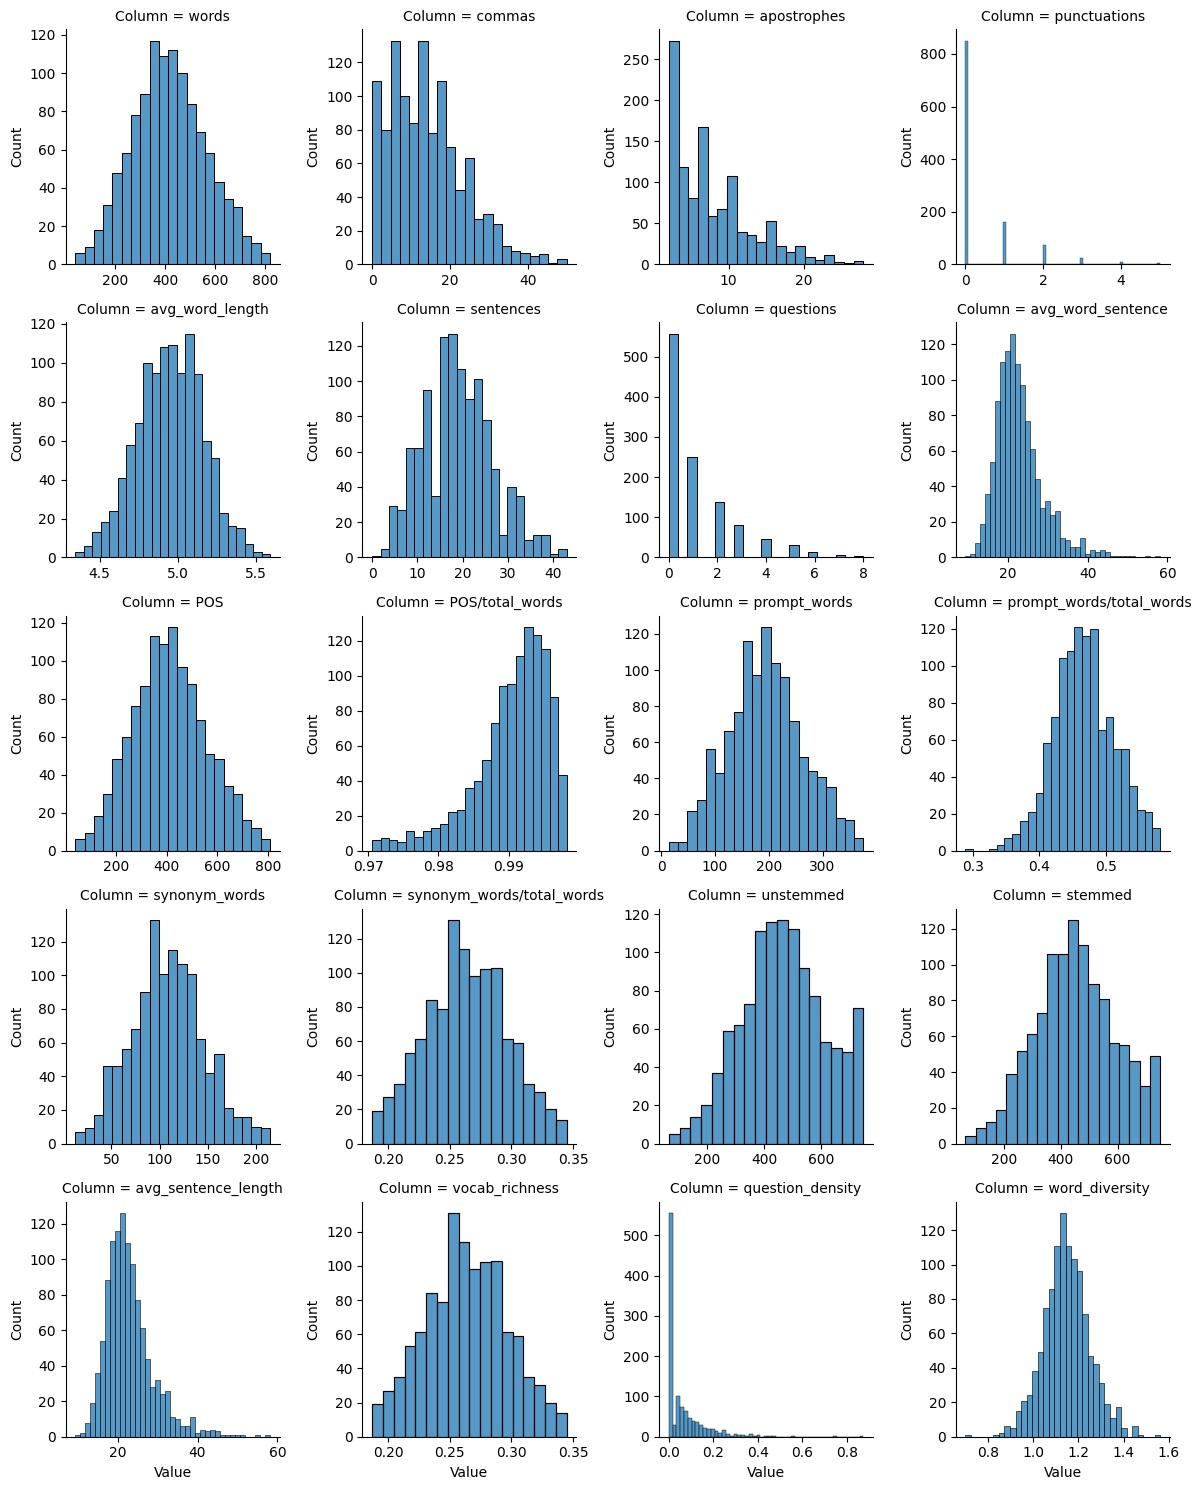

In [65]:
df_melted = X.melt(var_name='Column', value_name='Value')
g = sns.FacetGrid(df_melted, col='Column', col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, 'Value')
plt.tight_layout()
plt.show()

## 4. Description of the Decision Tree Model

The model used is a `DecisionTreeClassifier` from the `sklearn` library. A Decision Tree is a non-parametric supervised learning algorithm that performs classification by breaking down a dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed.

**Appropriate Options Selected:**
- **Criterion ('gini')**: This was selected to measure the quality of a split. Gini impurity calculates the probability of a specific variable being wrongly classified when chosen randomly. It is computationally efficient for multi-class problems like essay scoring.
- **Random State (42)**: This ensures that the splits generated by the tree are reproducible. In a coursework environment, this is vital so that the results and the tree structure remain consistent every time the code is executed.

## 5. Hyperparameter Tuning and Justification

For this model, two primary hyperparameters were tuned to balance the "Bias-Variance Tradeoff":

- `max_depth = 10`: This limits the maximum number of levels in the tree. Without this limit, the tree would continue to split until every essay in the training set is perfectly classified (Overfitting). By limiting it to 6, we force the model to learn broader patterns (like "long essays generally score higher") rather than memorizing the specific character counts of individual essays.
- `min_samples_split = 50`: This parameter specifies the minimum number of samples required to split an internal node.
  - **Why it’s appropriate**: Given that our dataset has some classes (like score 5) with very few samples, setting this to 50 prevents the model from creating "noisy" rules based on a tiny, non-representative group of essays. It encourages the model to find trends that apply to larger groups of students.

In [87]:
# Define the parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]          # we can also try both
}

# Set up GridSearchCV with 5‑fold stratified cross‑validation
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',          # you can also use 'f1_macro' or 'balanced_accuracy'
    n_jobs=-1,                    # use all processors
    verbose=1
)

# Fit on the resampled data
grid_dt.fit(X_train, y_train)

# Best parameters and score
print("Best parameters for Decision Tree:", grid_dt.best_params_)
print("Best cross‑validation accuracy:", grid_dt.best_score_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best parameters for Decision Tree: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 50}
Best cross‑validation accuracy: 0.6522222222222221


In [207]:
# 1. Initialize the model
dt_model = DecisionTreeClassifier(
    class_weight = None,
    criterion = 'gini',
    max_depth = 10,
    min_samples_leaf = 10,
    min_samples_split = 50,
    random_state = 42
)

# 2. Fit the model using the training data
dt_model.fit(X_train, y_train)
# dt_model.fit(X_resampled, y_resampled)

# 3. Make predictions on the test set
y_pred = dt_model.predict(X_test)

# 4. Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division = 0))

Decision Tree Accuracy: 0.6267

Detailed Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.78      0.44      0.56        16
           3       0.60      0.70      0.64        97
           4       0.65      0.63      0.64       101
           5       0.50      0.25      0.33         8
           6       0.00      0.00      0.00         1

    accuracy                           0.63       225
   macro avg       0.42      0.34      0.36       225
weighted avg       0.62      0.63      0.62       225



### Insight Extraction

We shall extract some insights, through finding the confusion as well as which feature having the highest significance.

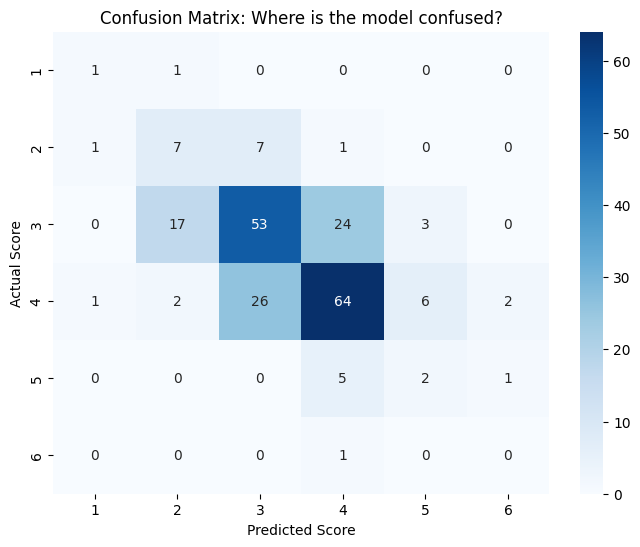

In [69]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues', 
    xticklabels = [1, 2, 3, 4, 5, 6],
    yticklabels = [1, 2, 3, 4, 5, 6]
)
plt.xlabel('Predicted Score')
plt.ylabel('Actual Score')
plt.title('Confusion Matrix: Where is the model confused?')
plt.show()

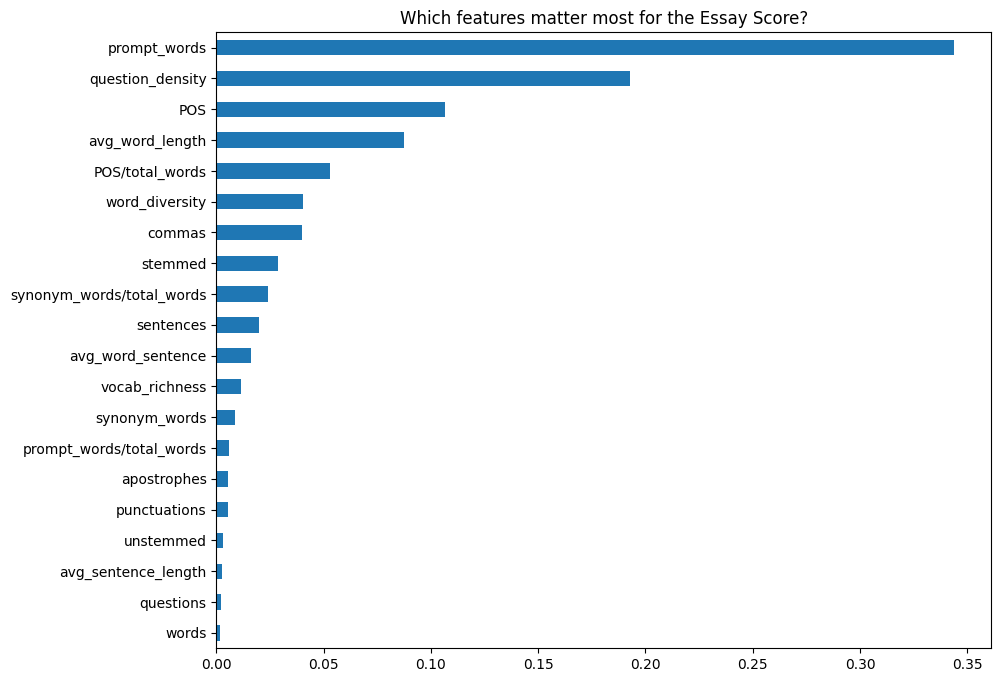

In [70]:
# Extract importance and match with column names
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Which features matter most for the Essay Score?')
plt.show()

## 6. Quadratic Weighted Kappa (QWK)

Quadratic Weighted Kappa (QWK) is the "secret sauce" of automated essay scoring. While Accuracy asks "Were you right or wrong?", **QWK** asks "How far off were you?"

In essay grading, predicting a 5 when the real score is 4 is a "small mistake." Predicting a 1 when the real score is 5 is a "disaster." QWK punishes the disaster much harder than the small mistake.

### How QWK Works (The Logic)

QWK measures the agreement between two raters (the Human and the model). It produces a score between -1 and 1:
- 1.0: Perfect agreement (Model is as good as the human).
- 0.0: Model is basically guessing randomly based on the distribution of scores.
- < 0: Model is performing worse than random guessing.

### The "Quadratic" part:

The penalty for an error grows quadratically (squared). If the difference between the actual score ($i$) and predicted score ($j$) is $|i - j|$, the penalty applied is $(i - j)^2$.

In [208]:
qwk_score = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk_score:.4f}")

Quadratic Weighted Kappa (QWK): 0.5315


## Using Random Forest instead (OPTIONAL)

In [88]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Best cross‑validation accuracy:", grid_rf.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best parameters for Random Forest: {'class_weight': None, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 20, 'n_estimators': 100}
Best cross‑validation accuracy: 0.6844444444444445


In [118]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    class_weight = None,
    max_depth = 20,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 20,
    n_estimators = 100,
    random_state = 42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluation
qwk_rf = cohen_kappa_score(y_test, y_pred_rf, weights='quadratic')
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest QWK: {qwk_rf:.4f}")

Random Forest Accuracy: 0.6844
Random Forest QWK: 0.6078


## What went wrong?

The case of low accuracy requires us to reflect why that may be the case. From our observation from reading the data, we see that:
1. The scores of 1, 5 and 6 are imbalanced, naturally, this would lead to biasness towards the score 3 and 4.

# Part 3: Kaggle Submission

In [209]:
# 1. Load the submission dataset
df_submission = pd.read_csv('data/F78DS-Essay-Features-Submission.csv')

# 2. Replicate Feature Engineering 
df_submission = feature_engineer(df_submission)

# 4. Predict the scores using your Decision Tree model
# Keep essayid for later, but remove it for prediction
submission_features = df_submission.drop(columns=['essayid'])
submission_predictions = dt_model.predict(submission_features)

# 5. Format for Kaggle
# Create a DataFrame with only the required columns
submission_df = pd.DataFrame({
    'essayid': df_submission['essayid'],
    'score': submission_predictions
})

# 6. Export to CSV
submission_df.to_csv('data/H00467830 - Too Qing Hao.csv', index=False)

print("Submission file created successfully!")
print(submission_df.head())
print(f"Total entries: {len(submission_df)}")

Submission file created successfully!
   essayid  score
0     1623      4
1     1143      3
2      660      4
3     1596      4
4      846      4
Total entries: 199
